In [2]:
import pandas as pd

df = pd.read_csv("job.csv")

df.head()

,Position,Title,Post Link,Company,Company Profile,Location,Actively Status,Description,Seniority level,Employment type,Job function,Industries,Time ago
0,1,Data Scientist,https://www.linkedin.com/jobs/view/data-scient...,T2S Solutions,https://www.linkedin.com/company/t2s-llc?trk=p...,"Maryland, United States",Be an early applicant,Summary\n\nT2S Solutions is currently seeking ...,Mid-Senior level,Full-time,Strategy/Planning and Information Technology,Defense & Space,1 month ago
1,2,Manager of Data Science,https://www.linkedin.com/jobs/view/manager-of-...,NiSource,https://www.linkedin.com/company/nisource?trk=...,"Columbus, Ohio Metropolitan Area",Actively Hiring,Full Time Perm\n\nShift: Hybrid – two days on ...,Mid-Senior level,Full-time,Engineering and Information Technology,"Utilities, Electric Power Generation, and Elec...",1 week ago
2,3,Senior Director of AI & Data,https://www.linkedin.com/jobs/view/senior-dire...,Nerdery,https://www.linkedin.com/company/nerdery?trk=p...,United States,Actively Hiring +8 benefits,Are You a Visionary Data & AI Leader? 🚀🚀\n\n\n...,Director,Full-time,Engineering and Information Technology,IT Services and IT Consulting,1 day ago
3,4,"Data Science Program, Full-Time Lecturer, Faculty",https://www.linkedin.com/jobs/view/data-scienc...,Middle Tennessee State University (MTSU),https://www.linkedin.com/school/middle-tenness...,"Murfreesboro, TN",Be an early applicant,"Job Title\n\nData Science Program, Full-Time L...",Entry level,Full-time,Engineering and Information Technology,Higher Education,6 days ago
4,5,"Technology Director, Search and Recommendation...",https://www.linkedin.com/jobs/view/technology-...,The Home Depot,https://www.linkedin.com/company/the-home-depo...,"Atlanta, GA",Actively Hiring,Req115857\n\nPosition Purpose\n\nThe Home Depo...,Not Applicable,Full-time,Other,Consumer Services,6 days ago


In [3]:
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Position         25 non-null     int64 
 1   Title            25 non-null     object
 2   Post Link        25 non-null     object
 3   Company          25 non-null     object
 4   Company Profile  25 non-null     object
 5   Location         25 non-null     object
 6   Actively Status  24 non-null     object
 7   Description      25 non-null     object
 8   Seniority level  25 non-null     object
 9   Employment type  25 non-null     object
 10  Job function     25 non-null     object
 11  Industries       25 non-null     object
 12  Time ago         25 non-null     object
dtypes: int64(1), object(12)
memory usage: 2.7+ KB


In [4]:
df = df.drop_duplicates()

In [6]:
df.columns

Index(['Position', 'Title', 'Post Link', 'Company', 'Company Profile',
       'Location', 'Actively Status', 'Description', 'Seniority level',
       'Employment type', 'Job function', 'Industries', 'Time ago'],
      dtype='object')

<Axes: xlabel='Title'>

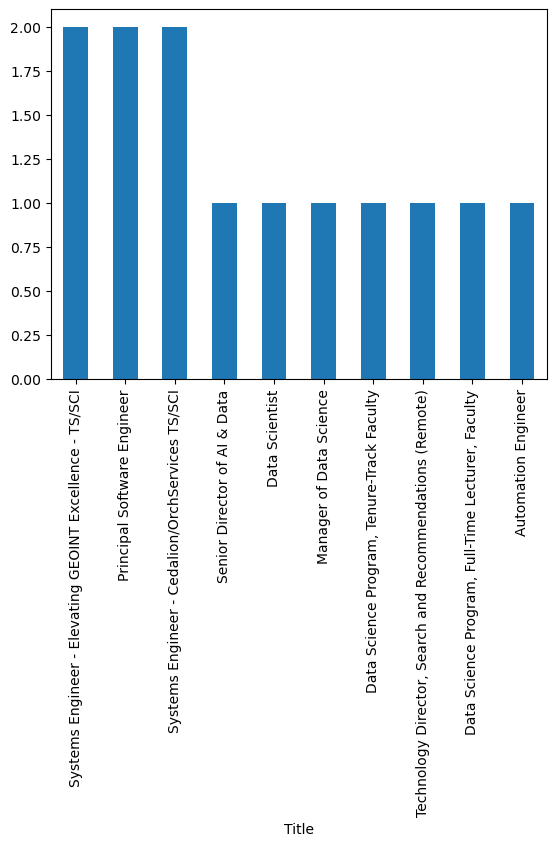

In [7]:
df['Title'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='Company'>

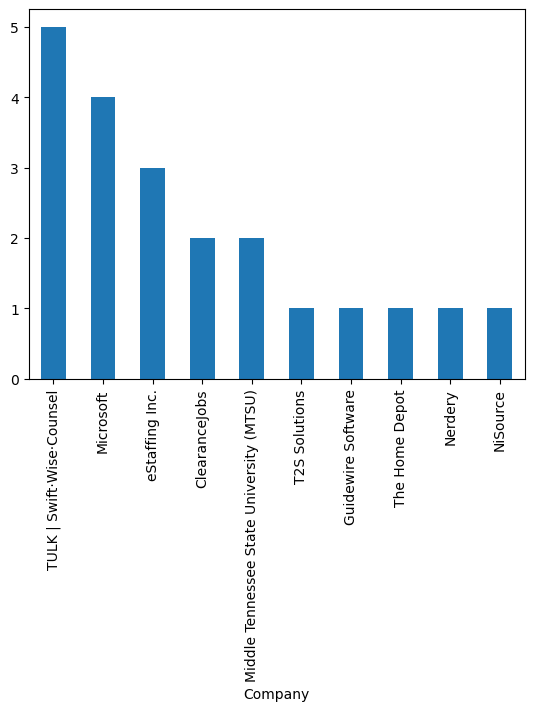

In [8]:
df['Company'].value_counts().head(10).plot(kind='bar')

<Axes: xlabel='Location'>

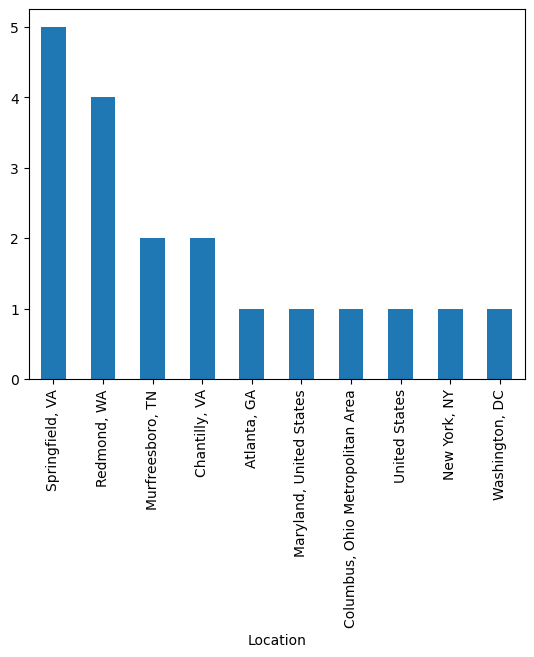

In [9]:
df['Location'].value_counts().head(10).plot(kind='bar')

In [10]:
skills_list = ['python', 'sql', 'excel', 'machine learning', 'data analysis']

for skill in skills_list:
    df[skill] = df['Description'].str.lower().str.contains(skill).astype(int)

<Axes: >

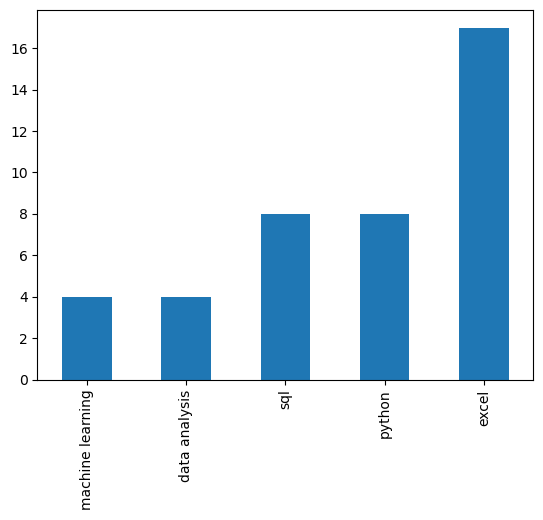

In [11]:
df[skills_list].sum().sort_values().plot(kind='bar')

<Axes: xlabel='Job function'>

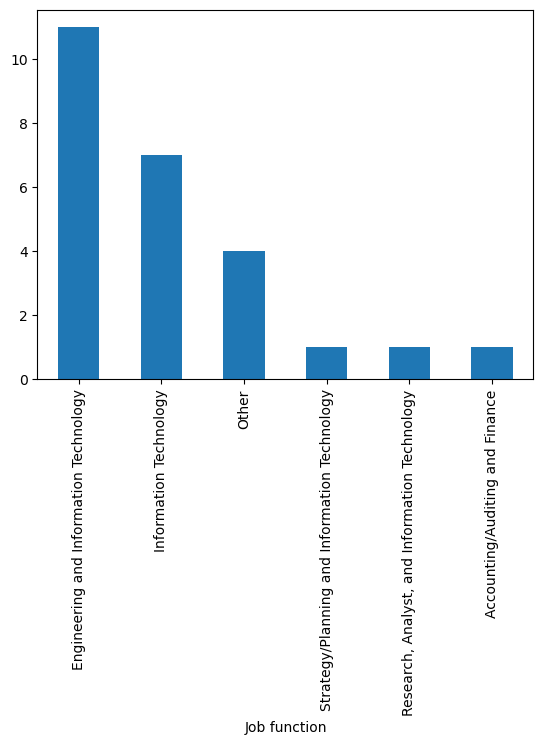

In [12]:
df['Job function'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

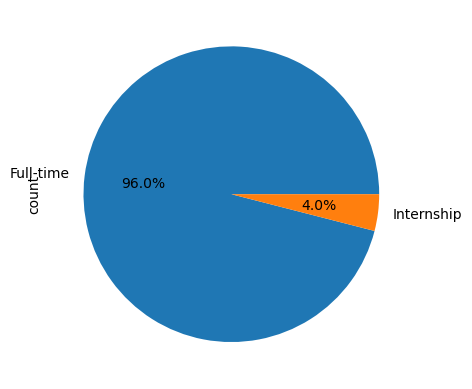

In [13]:
df['Employment type'].value_counts().plot(kind='pie', autopct='%1.1f%%')

<Axes: xlabel='Job function'>

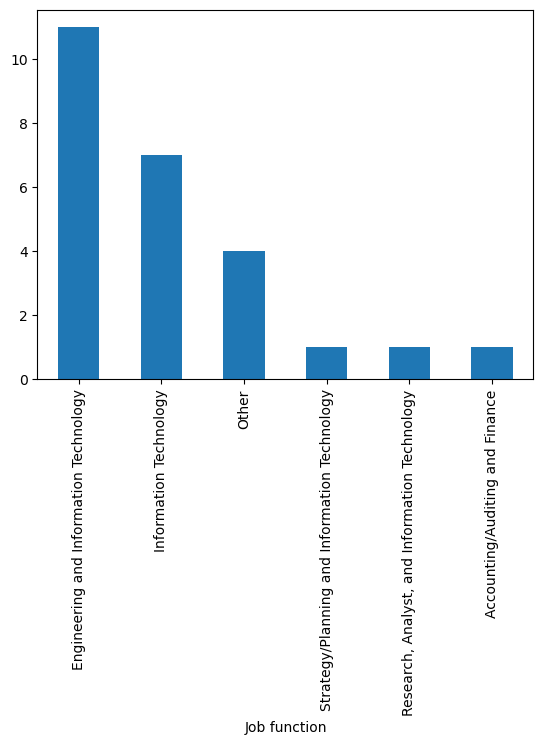

In [14]:
df['Job function'].value_counts().head(10).plot(kind='bar')

In [15]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

In [17]:
skills = ['python', 'sql', 'excel', 'machine learning', 'data analysis', 'power bi']

for skill in skills:
    df[skill] = df['description'].str.lower().str.contains(skill).astype(int)

In [18]:
df['skill_count'] = df[skills].sum(axis=1)

In [19]:
df.columns

Index(['position', 'title', 'post_link', 'company', 'company_profile',
       'location', 'actively_status', 'description', 'seniority_level',
       'employment_type', 'job_function', 'industries', 'time_ago', 'python',
       'sql', 'excel', 'machine_learning', 'data_analysis', 'machine learning',
       'data analysis', 'power bi', 'skill_count'],
      dtype='object')

In [20]:
for skill in skills:
    df[skill] = df['description'].str.contains(skill, case=False, na=False).astype(int)

In [21]:
df['high_demand'] = (df['skill_count'] > df['skill_count'].median()).astype(int)

In [23]:
df.columns

Index(['position', 'title', 'post_link', 'company', 'company_profile',
       'location', 'actively_status', 'description', 'seniority_level',
       'employment_type', 'job_function', 'industries', 'time_ago', 'python',
       'sql', 'excel', 'machine_learning', 'data_analysis', 'machine learning',
       'data analysis', 'power bi', 'skill_count', 'high_demand'],
      dtype='object')

In [24]:
skills = ['python', 'sql', 'excel', 'machine_learning', 'data_analysis']

In [25]:
df = df.drop(columns=['machine learning', 'data analysis', 'power bi'], errors='ignore')

In [26]:
df['skill_count'] = df[skills].sum(axis=1)

In [27]:
features = [
    'skill_count',
    'python',
    'sql',
    'excel',
    'machine_learning',
    'data_analysis'
]

In [28]:
X = df[features]
y = df['high_demand']

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [30]:
df['high_demand'] = (df['skill_count'] > df['skill_count'].median()).astype(int)

In [32]:
features = [
    'python',
    'sql',
    'excel',
    'machine_learning',
    'data_analysis'
]

In [33]:
X = df[features]
y = df['high_demand']

In [34]:
df['high_demand'] = (df['skill_count'] > df['skill_count'].median()).astype(int)

In [35]:
features = [
    'python',
    'sql',
    'excel',
    'machine_learning',
    'data_analysis'
]

In [36]:
X = df[features]
y = df['high_demand']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [39]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8


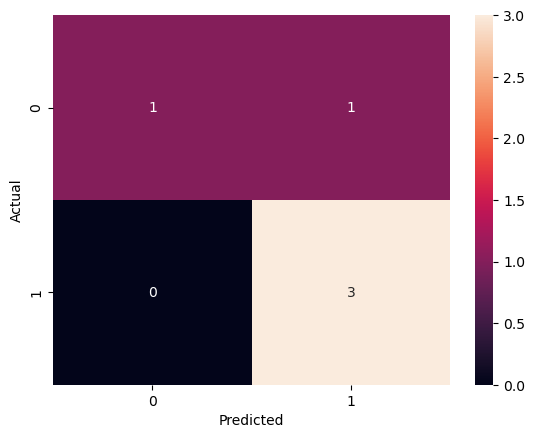

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         2
           1       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



<Axes: >

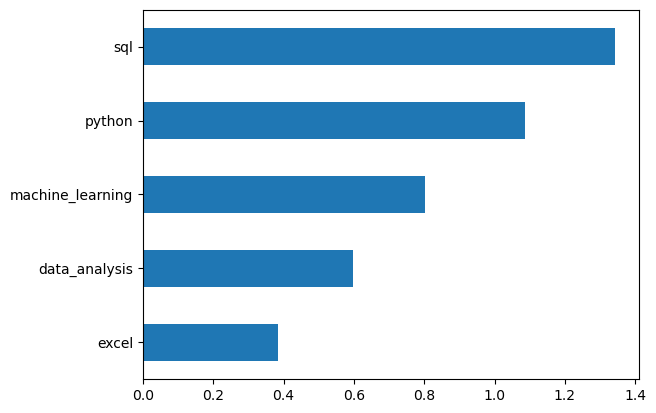

In [42]:
import pandas as pd

importance = pd.Series(model.coef_[0], index=features)
importance.sort_values().plot(kind='barh')